In [ ]:
# ======================================================
# Part 1 — Baseline Zero-Shot Evaluation
# ======================================================

In [ ]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

In [ ]:
!pip install -q transformers>=4.49.0 accelerate qwen-vl-utils==0.0.8 datasets pillow bitsandbytes

In [ ]:
import torch
from transformers import AutoProcessor, Qwen2_5_VLForConditionalGeneration, BitsAndBytesConfig
from qwen_vl_utils import process_vision_info

MODEL_ID = "Qwen/Qwen2.5-VL-3B-Instruct"

min_pixels = 256 * 28 * 28
max_pixels = 1280 * 28 * 28

processor = AutoProcessor.from_pretrained(
    MODEL_ID,
    min_pixels=min_pixels,
    max_pixels=max_pixels,
)

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_quant_type="nf4",
)

model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map={"": 0},
)
model.eval()
print("Model loaded on:", model.device)

preprocessor_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/1.05k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.37k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/5.70k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

...

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/216 [00:00<?, ?B/s]

Model loaded on: cuda:0


In [ ]:
import json, re

GROUNDING_PROMPT = (
    'You are looking at a screenshot that is {width}x{height} pixels.\n'
    'Find the UI element for this instruction: "{instruction}"\n'
    'Respond with ONLY a JSON object giving the pixel coordinate to click, '
    'in this exact format: {{"point": [x, y]}}\n'
    "x is measured from the left edge, y from the top edge. No other text."
)

def parse_point(text):
    try:
        match = re.search(r"\{.*\}", text, re.DOTALL)
        if match:
            obj = json.loads(match.group(0))
            pt = obj.get("point")
            if pt and len(pt) == 2:
                return float(pt[0]), float(pt[1])
    except Exception:
        pass
    nums = re.findall(r"-?\d+\.?\d*", text)
    if len(nums) >= 2:
        return float(nums[0]), float(nums[1])
    return None

@torch.inference_mode()
def predict_click(image, instruction, max_new_tokens=128):
    image = image.convert("RGB")
    orig_w, orig_h = image.size

    messages = [{
        "role": "user",
        "content": [
            {"type": "image", "image": image, "min_pixels": min_pixels, "max_pixels": max_pixels},
            {"type": "text", "text": GROUNDING_PROMPT.format(width=orig_w, height=orig_h, instruction=instruction)},
        ],
    }]

    text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    image_inputs, video_inputs = process_vision_info(messages)
    resized_w, resized_h = image_inputs[0].size

    inputs = processor(text=[text], images=image_inputs, videos=video_inputs, padding=True, return_tensors="pt").to(model.device)
    generated_ids = model.generate(**inputs, max_new_tokens=max_new_tokens)
    generated_ids = generated_ids[:, inputs.input_ids.shape[1]:]
    output_text = processor.batch_decode(generated_ids, skip_special_tokens=True, clean_up_tokenization_spaces=False)[0]

    point = parse_point(output_text)
    if point is None:
        return None
    x, y = point
    return x * (orig_w / resized_w), y * (orig_h / resized_h)

In [ ]:
from datasets import load_dataset

dataset = load_dataset("rootsautomation/ScreenSpot")["test"]
sample = dataset[0]
print("Instruction:", sample["instruction"])
print("Ground-truth bbox (x1,y1,x2,y2):", sample["bbox"])

pred = predict_click(sample["image"], sample["instruction"])
print("Predicted point:", pred)

README.md:   0%|          | 0.00/3.50k [00:00<?, ?B/s]

data/test-00000-of-00003.parquet: reconstructing file:   0%|          |  0.00B /  135MB            

data/test-00000-of-00003.parquet: downloading bytes:           |  0.00B            

data/test-00001-of-00003.parquet: reconstructing file:   0%|          |  0.00B /  199MB            

data/test-00001-of-00003.parquet: downloading bytes:           |  0.00B            

data/test-00002-of-00003.parquet: reconstructing file:   0%|          |  0.00B /  269MB            

data/test-00002-of-00003.parquet: downloading bytes:           |  0.00B            

Generating test split:   0%|          | 0/1272 [00:00<?, ? examples/s]

Instruction: close
Ground-truth bbox (x1,y1,x2,y2): [0.9479166666666666, 0.14444444444444443, 0.99375, 0.2074074074074074]
Predicted point: (925.7142857142857, 88.30827067669173)


In [ ]:
from collections import defaultdict

samples_per_source = defaultdict(list)
for sample in dataset:
    src = sample["data_source"]
    if len(samples_per_source[src]) < 3:
        samples_per_source[src].append(sample)

for src, samples in samples_per_source.items():
    print(f"=== {src} ===")
    for sample in samples:
        img_w, img_h = sample["image"].size
        pred = predict_click(sample["image"], sample["instruction"])
        x1, y1, x2, y2 = sample["bbox"]
        x1, x2, y1, y2 = x1*img_w, x2*img_w, y1*img_h, y2*img_h
        hit = pred is not None and x1 <= pred[0] <= x2 and y1 <= pred[1] <= y2
        print("instruction:", sample["instruction"])
        print(f"bbox (px): [{x1:.0f}, {y1:.0f}, {x2:.0f}, {y2:.0f}]")
        print("predicted:", pred, " HIT:" , hit)
        print()

=== windows ===
instruction: close
bbox (px): [910, 78, 954, 112]
predicted: (925.7142857142857, 88.30827067669173)  HIT: True

instruction: minimize this window
bbox (px): [835, 0, 871, 30]
predicted: (844.0336134453781, 12.18045112781955)  HIT: True

instruction: play the solitaire collection
bbox (px): [258, 139, 1658, 371]
predicted: (608.3890577507599, 315.989010989011)  HIT: True

=== macos ===
instruction: check my apple id
bbox (px): [1025, 141, 1129, 268]
predicted: (1078.5918367346937, 195.92261904761907)  HIT: True

instruction: view the language & region settings
bbox (px): [1018, 368, 1139, 515]
predicted: (1084.0530612244897, 472.9166666666667)  HIT: True

instruction: open time machine
bbox (px): [859, 952, 972, 1105]
predicted: (914.7551020408163, 1025.5535714285716)  HIT: True

=== ios ===
instruction: check the weather
bbox (px): [223, 78, 824, 671]
predicted: (519.7619047619047, 377.6847290640394)  HIT: True

instruction: view world clock
bbox (px): [879, 75, 1478, 3

In [ ]:
from collections import defaultdict
import time, json, os

LIMIT = None
CHECKPOINT_FILE = "/content/repo/eval_progress.json"

def point_in_bbox(x, y, bbox, img_w, img_h):
    x1, y1, x2, y2 = bbox
    x1, x2 = x1 * img_w, x2 * img_w
    y1, y2 = y1 * img_h, y2 * img_h
    return x1 <= x <= x2 and y1 <= y <= y2

if os.path.exists(CHECKPOINT_FILE):
    with open(CHECKPOINT_FILE) as f:
        state = json.load(f)
    per_sample = state["per_sample"]
    correct_by_group = defaultdict(lambda: [0, 0], {k: v for k, v in state["correct_by_group"].items()})
    start_idx = len(per_sample)
    print(f"Resuming from sample {start_idx}")
else:
    per_sample = []
    correct_by_group = defaultdict(lambda: [0, 0])
    start_idx = 0

eval_set = dataset if LIMIT is None else dataset.select(range(min(LIMIT, len(dataset))))
start = time.time()

for i in range(start_idx, len(eval_set)):
    sample = eval_set[i]
    img_w, img_h = sample["image"].size
    pred = predict_click(sample["image"], sample["instruction"])
    hit = pred is not None and point_in_bbox(pred[0], pred[1], sample["bbox"], img_w, img_h)
    per_sample.append({"instruction": sample["instruction"], "prediction": pred, "correct": hit,
                        "data_type": sample["data_type"], "data_source": sample["data_source"]})
    for key in (f"type:{sample['data_type']}", f"source:{sample['data_source']}", "overall"):
        correct_by_group[key][1] += 1
        if hit:
            correct_by_group[key][0] += 1

    if (i + 1) % 20 == 0:
        print(f"{i+1}/{len(eval_set)}  ({time.time()-start:.0f}s elapsed)")
        with open(CHECKPOINT_FILE, "w") as f:
            json.dump({"per_sample": per_sample, "correct_by_group": dict(correct_by_group)}, f)
        !cd /content/repo && git add eval_progress.json && git commit -m "checkpoint at {i+1}" -q && git push -q

print("\n=== Results ===")
for group, (c, t) in sorted(correct_by_group.items()):
    print(f"{group:20s}  {c/t*100:5.1f}%  ({c}/{t})")

Resuming from sample 180
200/1272  (209s elapsed)
220/1272  (361s elapsed)
240/1272  (543s elapsed)
260/1272  (723s elapsed)
280/1272  (907s elapsed)
300/1272  (1090s elapsed)
320/1272  (1265s elapsed)
340/1272  (1449s elapsed)
360/1272  (1628s elapsed)
380/1272  (1810s elapsed)
400/1272  (1993s elapsed)
420/1272  (2175s elapsed)
440/1272  (2359s elapsed)
460/1272  (2541s elapsed)
480/1272  (2725s elapsed)
500/1272  (2911s elapsed)
520/1272  (3096s elapsed)
540/1272  (3280s elapsed)
560/1272  (3464s elapsed)
580/1272  (3650s elapsed)
600/1272  (3835s elapsed)
620/1272  (4017s elapsed)
640/1272  (4199s elapsed)
660/1272  (4383s elapsed)
680/1272  (4566s elapsed)
700/1272  (4750s elapsed)
720/1272  (4936s elapsed)
740/1272  (5120s elapsed)
760/1272  (5305s elapsed)
780/1272  (5491s elapsed)
800/1272  (5676s elapsed)
820/1272  (5859s elapsed)
840/1272  (6043s elapsed)
860/1272  (6222s elapsed)
880/1272  (6402s elapsed)
900/1272  (6581s elapsed)
920/1272  (6760s elapsed)
940/1272  (6939s e

In [ ]:
import json
with open("/content/final_results.json", "w") as f:
    json.dump({"per_sample": per_sample, "correct_by_group": dict(correct_by_group)}, f)

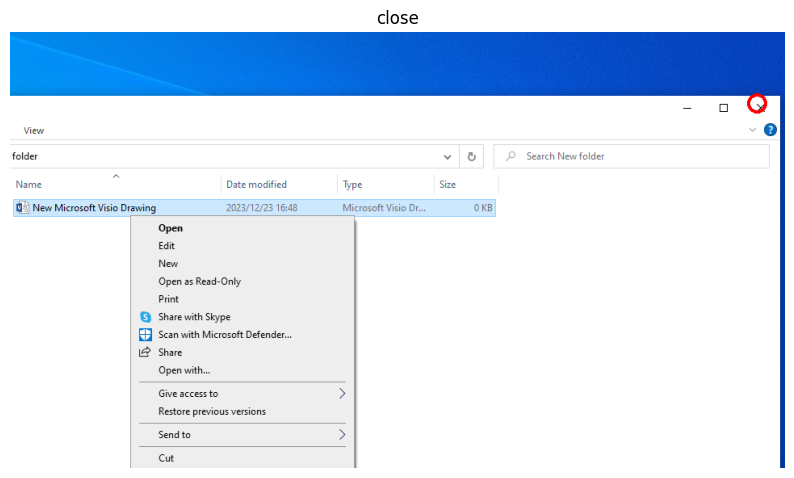

In [ ]:
from PIL import ImageDraw
import matplotlib.pyplot as plt

sample = dataset[0]
pred = predict_click(sample["image"], sample["instruction"])

marked = sample["image"].copy()
draw = ImageDraw.Draw(marked)
if pred:
    x, y = pred
    r = 12
    draw.ellipse([x-r, y-r, x+r, y+r], outline="red", width=4)

plt.figure(figsize=(10, 6))
plt.imshow(marked)
plt.title(sample["instruction"])
plt.axis("off")
plt.show()

In [ ]:
# ======================================================
# Part 2 — Custom Dataset Collection
# ======================================================

In [1]:
!pip install -q "transformers>=4.49.0" accelerate "qwen-vl-utils[decord]" bitsandbytes playwright
!playwright install chromium
!playwright install-deps chromium

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 MB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.7/47.7 MB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.5/35.5 MB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 42.1 MB/s eta 0:00:00
184.3 MiB [] 0% 759.5s184.3 MiB [] 0% 57.0s184.3 MiB [] 0% 36.9s184.3 MiB [] 0% 23.0s184.3 MiB [] 0% 21.6s184.3 MiB [] 0% 12.9s184.3 MiB [] 1% 8.4s184.3 MiB [] 1% 6.8s184.3 MiB [] 2% 5.7s184.3 MiB [] 3% 4.8s184.3 MiB [] 3% 4.4s184.3 MiB [] 4% 4.1s184.3 MiB [] 4% 4.2s184.3 MiB [] 4% 4.3s184.3 MiB [] 5% 4.2s184.3 MiB [] 5% 4.1s184.3 MiB [] 6% 3.9s184.3 MiB [] 6% 4.1s184.3 MiB [] 7% 4.3s184.3 MiB [] 7% 4.6s184.3 MiB [] 7% 4.7s184.3 MiB [] 8% 4.4s184.3 MiB [] 9% 4.1s184.3 MiB [] 10% 3.8s184.3 MiB [] 11% 3.6s184.3 MiB [] 11% 3.5s184.3 MiB [] 12% 3.4s184.3 MiB [] 13% 3.2s184.3 MiB [] 14% 3.1s184.3 MiB [] 15% 3.0s184.3 MiB [] 15% 2.9s184.3 MiB [] 17% 2.7s184.3 MiB [] 18% 2.7s184.3 M

In [2]:
import torch
from transformers import AutoProcessor, Qwen2_5_VLForConditionalGeneration, BitsAndBytesConfig
from qwen_vl_utils import process_vision_info

MODEL_ID = "Qwen/Qwen2.5-VL-3B-Instruct"
min_pixels = 256 * 28 * 28
max_pixels = 1280 * 28 * 28

processor = AutoProcessor.from_pretrained(
    MODEL_ID,
    min_pixels=min_pixels,
    max_pixels=max_pixels,
)

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_quant_type="nf4",
)

model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map={"": 0},
)
model.eval()
print("Model loaded on:", model.device)

preprocessor_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/1.05k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.37k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/5.70k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

...

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/216 [00:00<?, ?B/s]

Model loaded on: cuda:0


In [19]:
@torch.inference_mode()
def predict_click(image, instruction, max_new_tokens=128):
    image = image.convert("RGB")
    orig_w, orig_h = image.size

    messages = [{
        "role": "user",
        "content": [
            {"type": "image", "image": image, "min_pixels": min_pixels, "max_pixels": max_pixels},
            {"type": "text", "text": GROUNDING_PROMPT.format(width=orig_w, height=orig_h, instruction=instruction)},
        ],
    }]

    text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    image_inputs, video_inputs = process_vision_info(messages)

    inputs = processor(
        text=[text],
        images=image_inputs,
        videos=video_inputs,
        padding=True,
        return_tensors="pt",
    ).to(model.device)

    generated_ids = model.generate(**inputs, max_new_tokens=max_new_tokens)
    generated_ids = generated_ids[:, inputs.input_ids.shape[1]:]
    output_text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]

    return parse_point(output_text)

In [4]:
import asyncio, json, os
from playwright.async_api import async_playwright

OUTPUT_DIR = "/content/gui_dataset"
os.makedirs(f"{OUTPUT_DIR}/images", exist_ok=True)

SELECTOR = "button, a, input, [role=button], [role=link], select, textarea"
MAX_PER_SITE = 80  # stops generic sites (GitHub, HN) from drowning out fintech samples

URLS = [
    # --- Pakistani fintech (the differentiator) ---
    "https://www.jazzcash.com.pk",
    "https://jazzcash.online",
    "https://easypaisa.com.pk",
    "https://sadapay.pk",
    "https://www.nayapay.com",
    "https://ubldigital.com",
    "https://www.hbl.com/personal/digital-banking",
    "https://www.meezanbank.com/ways-to-bank",
    # --- General sites (diversity, avoids overfitting to only fintech UI patterns) ---
    "https://www.wikipedia.org",
    "https://github.com",
    "https://news.ycombinator.com",
]

async def get_label(el):
    text = (await el.inner_text() or "").strip()
    aria = await el.get_attribute("aria-label")
    placeholder = await el.get_attribute("placeholder")
    title = await el.get_attribute("title")
    label = text or aria or placeholder or title
    if not label:
        # icon-only buttons/links often carry their name on a child <img alt="...">
        try:
            label = await el.eval_on_selector("img", "img => img.alt || null")
        except Exception:
            label = None
    return label


async def collect_from_page(page, url, dataset, idx):
    try:
        await page.goto(url, wait_until="domcontentloaded", timeout=25000)
        await page.wait_for_timeout(2000)  # let JS content settle without waiting on full networkidle
    except Exception as e:
        print(f"  Skipping {url} — failed to load ({e})")
        return idx

    elements = await page.query_selector_all(SELECTOR)
    site_count = 0

    for el in elements:
        if site_count >= MAX_PER_SITE:
            break
        try:
            await el.scroll_into_view_if_needed(timeout=2000)
        except Exception:
            continue

        box = await el.bounding_box()
        if box is None or box["width"] < 4 or box["height"] < 4:
            continue

        label = await get_label(el)
        if not label or len(label) > 60:
            continue

        img_path = f"{OUTPUT_DIR}/images/{idx}.png"
        await page.screenshot(path=img_path)

        cx = box["x"] + box["width"] / 2
        cy = box["y"] + box["height"] / 2

        dataset.append({
            "image": img_path,
            "instruction": f"click {label.strip()}",
            "point": [cx, cy],
            "bbox": [box["x"], box["y"], box["x"] + box["width"], box["y"] + box["height"]],
            "source_url": url,
        })
        idx += 1
        site_count += 1

    return idx


async def build_dataset():
    dataset, idx = [], 0
    async with async_playwright() as p:
        browser = await p.chromium.launch()
        page = await browser.new_page(viewport={"width": 1280, "height": 800})
        for url in URLS:
            print(f"Scraping {url} ...")
            idx = await collect_from_page(page, url, dataset, idx)
            print(f"  -> {idx} total samples so far")
        await browser.close()

    with open(f"{OUTPUT_DIR}/dataset.json", "w") as f:
        json.dump(dataset, f, indent=2)
    print(f"\nDone. Collected {len(dataset)} labeled samples -> {OUTPUT_DIR}/dataset.json")


await build_dataset()

Scraping https://www.jazzcash.com.pk ...
  -> 80 total samples so far
Scraping https://jazzcash.online ...
  -> 103 total samples so far
Scraping https://easypaisa.com.pk ...
  -> 103 total samples so far
Scraping https://sadapay.pk ...
  -> 122 total samples so far
Scraping https://www.nayapay.com ...
  -> 153 total samples so far
Scraping https://ubldigital.com ...
  Skipping https://ubldigital.com — failed to load (Page.goto: Timeout 25000ms exceeded.
Call log:
  - navigating to "https://ubldigital.com/", waiting until "domcontentloaded"
)
  -> 153 total samples so far
Scraping https://www.hbl.com/personal/digital-banking ...
  -> 153 total samples so far
Scraping https://www.meezanbank.com/ways-to-bank ...
  -> 155 total samples so far
Scraping https://www.wikipedia.org ...
  -> 235 total samples so far
Scraping https://github.com ...
  -> 315 total samples so far
Scraping https://news.ycombinator.com ...
  -> 395 total samples so far

Done. Collected 395 labeled samples -> /conten

In [ ]:
#WEEK 2 — LoRA Fine-Tuning

In [5]:
!pip install -q peft

In [7]:
import json, random

with open("/content/gui_dataset/dataset.json") as f:
    raw_data = json.load(f)

random.seed(42)
random.shuffle(raw_data)
split = int(0.9 * len(raw_data))
train_data = raw_data[:split]
val_data = raw_data[split:]

print(f"Train: {len(train_data)} | Val: {len(val_data)}")

Train: 355 | Val: 40


In [8]:
import torch
from PIL import Image

def build_training_example(record):
    image = Image.open(record["image"]).convert("RGB")
    w, h = image.size
    x, y = record["point"]
    instruction = record["instruction"]

    user_content = [
        {"type": "image", "image": image, "min_pixels": min_pixels, "max_pixels": max_pixels},
        {"type": "text", "text": GROUNDING_PROMPT.format(width=w, height=h, instruction=instruction)},
    ]
    target_text = json.dumps({"point": [round(x), round(y)]})

    prompt_messages = [{"role": "user", "content": user_content}]
    full_messages = [
        {"role": "user", "content": user_content},
        {"role": "assistant", "content": target_text},
    ]

    prompt_text = processor.apply_chat_template(prompt_messages, tokenize=False, add_generation_prompt=True)
    full_text = processor.apply_chat_template(full_messages, tokenize=False, add_generation_prompt=False)

    image_inputs, video_inputs = process_vision_info(prompt_messages)

    prompt_enc = processor(text=[prompt_text], images=image_inputs, videos=video_inputs, return_tensors="pt")
    full_enc = processor(text=[full_text], images=image_inputs, videos=video_inputs, return_tensors="pt")

    input_ids = full_enc.input_ids[0]
    labels = input_ids.clone()
    prompt_len = prompt_enc.input_ids.shape[1]
    labels[:prompt_len] = -100  # mask the prompt — model only learns to predict the JSON answer

    full_enc["labels"] = labels.unsqueeze(0)
    return full_enc

In [9]:
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

model = prepare_model_for_kbit_training(model, use_gradient_checkpointing=True)

lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()  # should show a small % of total params — that's LoRA working correctly

trainable params: 37,152,768 || all params: 3,791,775,744 || trainable%: 0.9798


In [10]:
from torch.optim import AdamW
import os, shutil, json, time

for name in ["model", "processor", "GROUNDING_PROMPT", "min_pixels", "max_pixels", "train_data"]:
    if name not in globals():
        raise RuntimeError(f"'{name}' is not defined. Run Cell 2/3/6 first.")

if not os.path.exists("/content/drive/MyDrive"):
    from google.colab import drive
    for attempt in range(3):
        try:
            drive.mount('/content/drive', force_remount=True)
            print("Drive mounted successfully")
            break
        except Exception as e:
            print(f"Mount attempt {attempt+1} failed: {e}")
            time.sleep(10)
    else:
        raise RuntimeError("Drive mount failed after 3 attempts. Restart runtime and try again.")
else:
    print("Drive already mounted")

GRAD_ACCUM_STEPS = 8
LR = 1e-4
CHECKPOINT_STATE_FILE = "/content/drive/MyDrive/training_state.json"

optimizer = AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=LR)
total_steps_per_epoch = len(train_data) // GRAD_ACCUM_STEPS

def load_state():
    if os.path.exists(CHECKPOINT_STATE_FILE):
        with open(CHECKPOINT_STATE_FILE) as f:
            return json.load(f)
    return {"completed_epochs": 0}

state = load_state()
print("Current state:", state)
if state["completed_epochs"] > 0:
    last_ckpt = f"/content/drive/MyDrive/screensight_lora_epoch{state['completed_epochs']}"
    weight_file = f"{last_ckpt}/adapter_model.safetensors"
    if os.path.exists(weight_file):
        size_mb = os.path.getsize(weight_file) / (1024*1024)
        print(f"Loading verified adapter from epoch {state['completed_epochs']} ({size_mb:.1f} MB)")
        model.load_adapter(last_ckpt, adapter_name="default", is_trainable=True)
    else:
        raise RuntimeError(f"State says epoch {state['completed_epochs']} done, but weight file missing at {weight_file}")
else:
    print("No previous progress — starting fresh")


def train_one_epoch(epoch_number):
    state = load_state()
    if state["completed_epochs"] >= epoch_number:
        print(f"Epoch {epoch_number} already completed — skipping.")
        return

    model.train()
    random.shuffle(train_data)
    running_loss, skipped, step = 0.0, 0, 0
    run_start = time.time()
    optimizer.zero_grad()

    for i, record in enumerate(train_data):
        try:
            batch = build_training_example(record)
        except Exception as e:
            skipped += 1
            if skipped <= 3:
                print(f"Skipping sample due to error: {e}")
            if skipped > 20 and skipped == i + 1:
                raise RuntimeError(f"All {skipped} samples failed — stopping.")
            continue

        batch = {k: v.to(model.device) if torch.is_tensor(v) else v for k, v in batch.items()}
        outputs = model(**batch)
        loss = outputs.loss / GRAD_ACCUM_STEPS
        loss.backward()
        running_loss += loss.item()

        if (i + 1) % GRAD_ACCUM_STEPS == 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            optimizer.zero_grad()
            step += 1
            pct = 100 * step / total_steps_per_epoch
            elapsed = time.time() - run_start
            print(f"Epoch {epoch_number} | Step {step}/{total_steps_per_epoch} | Loss: {running_loss:.4f} | {pct:.1f}% | {elapsed/60:.1f}m")
            running_loss = 0.0

    if skipped:
        print(f"Epoch {epoch_number}: {skipped}/{len(train_data)} samples skipped")

    save_dir_local = f"/content/screensight_lora_epoch{epoch_number}"
    save_dir_drive = f"/content/drive/MyDrive/screensight_lora_epoch{epoch_number}"
    model.save_pretrained(save_dir_local)
    shutil.copytree(save_dir_local, save_dir_drive, dirs_exist_ok=True)

    weight_file = f"{save_dir_drive}/adapter_model.safetensors"
    if not os.path.exists(weight_file) or os.path.getsize(weight_file) < 1_000_000:
        raise RuntimeError(f"Save verification failed for epoch {epoch_number} — weight file missing or too small at {weight_file}")

    size_mb = os.path.getsize(weight_file) / (1024*1024)
    with open(CHECKPOINT_STATE_FILE, "w") as f:
        json.dump({"completed_epochs": epoch_number}, f)
    print(f"Epoch {epoch_number} saved and VERIFIED on Drive ({size_mb:.1f} MB)")

print("Setup done (Drive-only, no GitHub). Now run Cell 9a,9b and then 9c")

Drive already mounted
Current state: {'completed_epochs': 0}
No previous progress — starting fresh
Setup done (Drive-only, no GitHub). Now run Cell 9a,9b and then 9c


In [ ]:
train_one_epoch(1)

/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
[transformers] `use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.


Epoch 1 | Step 1/53 | Loss: 0.9303 | 1.9% | 3.6m
Epoch 1 | Step 2/53 | Loss: 0.6164 | 3.8% | 7.1m
Epoch 1 | Step 3/53 | Loss: 0.7748 | 5.7% | 10.7m
Epoch 1 | Step 4/53 | Loss: 0.7093 | 7.5% | 14.2m
Epoch 1 | Step 5/53 | Loss: 0.5379 | 9.4% | 17.8m
Epoch 1 | Step 6/53 | Loss: 0.7102 | 11.3% | 21.3m
Epoch 1 | Step 7/53 | Loss: 0.7307 | 13.2% | 24.9m
Epoch 1 | Step 8/53 | Loss: 0.8512 | 15.1% | 28.4m
Epoch 1 | Step 9/53 | Loss: 0.7628 | 17.0% | 32.0m
Epoch 1 | Step 10/53 | Loss: 0.7971 | 18.9% | 35.5m
Epoch 1 | Step 11/53 | Loss: 0.5751 | 20.8% | 39.1m
Epoch 1 | Step 12/53 | Loss: 0.6888 | 22.6% | 42.6m
Epoch 1 | Step 13/53 | Loss: 0.7018 | 24.5% | 46.2m
Epoch 1 | Step 14/53 | Loss: 0.6796 | 26.4% | 49.7m
Epoch 1 | Step 15/53 | Loss: 0.5695 | 28.3% | 53.3m
Epoch 1 | Step 16/53 | Loss: 0.7144 | 30.2% | 56.8m
Epoch 1 | Step 17/53 | Loss: 0.5509 | 32.1% | 60.4m
Epoch 1 | Step 18/53 | Loss: 0.6679 | 34.0% | 63.9m
Epoch 1 | Step 19/53 | Loss: 0.6228 | 35.8% | 67.5m
Epoch 1 | Step 20/53 | Loss:

CalledProcessError: Command '['git', '-C', '/content/repo', 'push']' returned non-zero exit status 1.

In [ ]:
train_one_epoch(2)

/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
[transformers] `use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.


Epoch 2 | Step 1/44 | Loss: 0.7849 | 2.3% | 3.6m
Epoch 2 | Step 2/44 | Loss: 1.0227 | 4.5% | 7.2m
Epoch 2 | Step 3/44 | Loss: 0.7206 | 6.8% | 10.7m
Epoch 2 | Step 4/44 | Loss: 0.7385 | 9.1% | 14.3m
Epoch 2 | Step 5/44 | Loss: 0.7268 | 11.4% | 17.8m
Epoch 2 | Step 6/44 | Loss: 0.6484 | 13.6% | 21.4m
Epoch 2 | Step 7/44 | Loss: 0.7587 | 15.9% | 24.9m
Epoch 2 | Step 8/44 | Loss: 0.6492 | 18.2% | 28.5m
Epoch 2 | Step 9/44 | Loss: 0.6955 | 20.5% | 32.1m
Epoch 2 | Step 10/44 | Loss: 0.7217 | 22.7% | 35.6m
Epoch 2 | Step 11/44 | Loss: 0.6987 | 25.0% | 39.2m
Epoch 2 | Step 12/44 | Loss: 0.6904 | 27.3% | 42.7m
Epoch 2 | Step 13/44 | Loss: 0.6670 | 29.5% | 46.3m
Epoch 2 | Step 14/44 | Loss: 0.6557 | 31.8% | 49.8m
Epoch 2 | Step 15/44 | Loss: 0.6210 | 34.1% | 53.4m
Epoch 2 | Step 16/44 | Loss: 0.6497 | 36.4% | 56.9m
Epoch 2 | Step 17/44 | Loss: 0.6120 | 38.6% | 60.5m
Epoch 2 | Step 18/44 | Loss: 0.7369 | 40.9% | 64.1m
Epoch 2 | Step 19/44 | Loss: 0.8285 | 43.2% | 67.6m
Epoch 2 | Step 20/44 | Loss

CalledProcessError: Command '['git', '-C', '/content/repo', 'push']' returned non-zero exit status 1.

In [11]:
train_one_epoch(3)

/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
[transformers] `use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.


Epoch 3 | Step 1/44 | Loss: 0.8437 | 2.3% | 3.3m
Epoch 3 | Step 2/44 | Loss: 0.8276 | 4.5% | 6.7m
Epoch 3 | Step 3/44 | Loss: 0.6883 | 6.8% | 10.1m
Epoch 3 | Step 4/44 | Loss: 0.8201 | 9.1% | 13.5m
Epoch 3 | Step 5/44 | Loss: 0.7614 | 11.4% | 16.9m
Epoch 3 | Step 6/44 | Loss: 0.7252 | 13.6% | 20.3m
Epoch 3 | Step 7/44 | Loss: 0.6232 | 15.9% | 23.7m
Epoch 3 | Step 8/44 | Loss: 0.7055 | 18.2% | 27.2m
Epoch 3 | Step 9/44 | Loss: 0.6794 | 20.5% | 30.6m
Epoch 3 | Step 10/44 | Loss: 0.7221 | 22.7% | 34.0m
Epoch 3 | Step 11/44 | Loss: 0.7937 | 25.0% | 37.4m
Epoch 3 | Step 12/44 | Loss: 0.5988 | 27.3% | 40.8m
Epoch 3 | Step 13/44 | Loss: 0.7115 | 29.5% | 44.2m
Epoch 3 | Step 14/44 | Loss: 0.6556 | 31.8% | 47.6m
Epoch 3 | Step 15/44 | Loss: 0.6141 | 34.1% | 51.0m
Epoch 3 | Step 16/44 | Loss: 0.5604 | 36.4% | 54.4m
Epoch 3 | Step 17/44 | Loss: 0.5787 | 38.6% | 57.8m
Epoch 3 | Step 18/44 | Loss: 0.5902 | 40.9% | 61.2m
Epoch 3 | Step 19/44 | Loss: 0.5949 | 43.2% | 64.6m
Epoch 3 | Step 20/44 | Loss

In [28]:
#WEEK 3 — LoRA Fine-Tuning

In [14]:
record = val_data[0]
image = Image.open(record["image"]).convert("RGB")
print("Image size:", image.size)
print("Ground truth bbox:", record["bbox"])

orig_w, orig_h = image.size
messages = [{
    "role": "user",
    "content": [
        {"type": "image", "image": image, "min_pixels": min_pixels, "max_pixels": max_pixels},
        {"type": "text", "text": GROUNDING_PROMPT.format(width=orig_w, height=orig_h, instruction=record["instruction"])},
    ],
}]
text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
image_inputs, video_inputs = process_vision_info(messages)
resized_w, resized_h = image_inputs[0].size
inputs = processor(text=[text], images=image_inputs, videos=video_inputs, padding=True, return_tensors="pt").to(model.device)

with model.disable_adapter():
    generated_ids = model.generate(**inputs, max_new_tokens=128)
generated_ids = generated_ids[:, inputs.input_ids.shape[1]:]
output_text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]

print("\nRaw model output:", repr(output_text))
print("Parsed point:", parse_point(output_text))

Image size: (1280, 800)
Ground truth bbox: [998.96875, 560.75, 1026.96875, 576.75]

Raw model output: '{"point": [443, 336]}'
Parsed point: (443.0, 336.0)


In [21]:
# Cell 11 — Before/After on Your Held-Out Data (with debug output)

import torch
from PIL import Image
from collections import Counter

def point_in_bbox(point, bbox):
    if point is None:
        return False
    x, y = point
    x1, y1, x2, y2 = bbox
    return x1 <= x <= x2 and y1 <= y <= y2

@torch.inference_mode()
def predict_click_with_mode(image, instruction, use_finetuned=True):
    if use_finetuned:
        return predict_click(image, instruction)
    else:
        with model.disable_adapter():
            return predict_click(image, instruction)

FINTECH_DOMAINS = ["jazzcash", "easypaisa", "sadapay", "nayapay", "ubldigital", "hbl.com", "meezanbank"]

# --- check val_data composition before trusting fintech% ---
site_counts = Counter()
for r in val_data:
    matched = next((d for d in FINTECH_DOMAINS if d in r["source_url"]), "OTHER/general")
    site_counts[matched] += 1
print("val_data composition by site:")
for site, count in site_counts.items():
    print(f"  {site}: {count}")
print(f"Total val_data: {len(val_data)}\n")

def evaluate_on_holdout(data, use_finetuned, debug=True, debug_n=10):
    correct = total = 0
    fintech_correct = fintech_total = 0
    none_count = 0

    for idx, record in enumerate(data):
        image = Image.open(record["image"]).convert("RGB")
        pred = predict_click_with_mode(image, record["instruction"], use_finetuned=use_finetuned)

        if pred is None:
            none_count += 1

        ok = point_in_bbox(pred, record["bbox"])
        correct += ok
        total += 1

        if any(d in record["source_url"] for d in FINTECH_DOMAINS):
            fintech_total += 1
            fintech_correct += ok

        if debug and idx < debug_n:
            print(f"  [{idx}] instr={record['instruction']!r}")
            print(f"       pred={pred}  bbox={record['bbox']}  in_bbox={ok}  url={record['source_url']}")

    overall = 100 * correct / total if total else 0
    fintech = 100 * fintech_correct / fintech_total if fintech_total else 0
    print(f"\n  -> None predictions: {none_count}/{total}")
    return overall, fintech, total, fintech_total

print("=== Evaluating ZERO-SHOT (base model, LoRA disabled) ===")
zs_overall, zs_fintech, n_total, n_fintech = evaluate_on_holdout(val_data, use_finetuned=False)
print(f"Zero-shot  -> Overall: {zs_overall:.1f}%  |  Fintech-only: {zs_fintech:.1f}%  (n={n_fintech}/{n_total})")

print("\n=== Evaluating FINE-TUNED model ===")
ft_overall, ft_fintech, _, _ = evaluate_on_holdout(val_data, use_finetuned=True)
print(f"Fine-tuned -> Overall: {ft_overall:.1f}%  |  Fintech-only: {ft_fintech:.1f}%")

print(f"\nImprovement -> Overall: {ft_overall - zs_overall:+.1f} pts  |  Fintech: {ft_fintech - zs_fintech:+.1f} pts")


  -> None predictions: 3/40
Zero-shot  -> Overall: 22.5%  |  Fintech-only: 31.6%  (n=19/40)

=== Evaluating FINE-TUNED model ===
  [0] instr='click Zhōngwén'
       pred=(649.0, 569.0)  bbox=[998.96875, 560.75, 1026.96875, 576.75]  in_bbox=False  url=https://www.wikipedia.org
  [1] instr='click 332\xa0comments'
       pred=(369.0, 405.0)  bbox=[334.6875, 401, 395.875, 411]  in_bbox=True  url=https://news.ycombinator.com
  [2] instr='click 30\xa0comments'
       pred=(346.0, 305.0)  bbox=[308.75, 231, 364.75, 241]  in_bbox=False  url=https://news.ycombinator.com
  [3] instr='click korisne.com.ua'
       pred=(640.0, 263.0)  bbox=[140, 251.59375, 1140, 269.59375]  in_bbox=True  url=https://jazzcash.online
  [4] instr='click Arrow Right'
       pred=(439.0, 500.0)  bbox=[268, 159.53125, 632.109375, 215.53125]  in_bbox=False  url=https://www.jazzcash.com.pk
  [5] instr='click NayaPay Instagram'
       pred=(186.0, 634.0)  bbox=[171.671875, 627.71875, 199.671875, 643.71875]  in_bbox=True  

In [22]:
# Cell 11b — Quantify prediction collapse across full val_data

from collections import Counter

def collect_predictions(data, use_finetuned):
    preds = []
    for record in data:
        image = Image.open(record["image"]).convert("RGB")
        pred = predict_click_with_mode(image, record["instruction"], use_finetuned=use_finetuned)
        preds.append((record["instruction"], pred, record["source_url"]))
    return preds

ft_preds = collect_predictions(val_data, use_finetuned=True)

# round to nearest few px so near-identical points still group together
rounded = Counter(
    (round(p[0]/5)*5, round(p[1]/5)*5) if p is not None else None
    for _, p, _ in ft_preds
)

print("Most common fine-tuned predicted points (rounded to nearest 5px):")
for point, count in rounded.most_common(5):
    print(f"  {point}: {count} times")

print("\nInstructions that share the most common point:")
if rounded.most_common(1):
    top_point = rounded.most_common(1)[0][0]
    for instr, p, url in ft_preds:
        if p is not None and (round(p[0]/5)*5, round(p[1]/5)*5) == top_point:
            print(f"  {instr!r}  <-  {url}")

Most common fine-tuned predicted points (rounded to nearest 5px):
  (295, 340): 5 times
  (650, 570): 4 times
  (440, 500): 2 times
  (1135, 55): 2 times
  (605, 295): 2 times

Instructions that share the most common point:
  'click hide'  <-  https://news.ycombinator.com
  'click hide'  <-  https://news.ycombinator.com
  'click hide'  <-  https://news.ycombinator.com
  'click hide'  <-  https://news.ycombinator.com
  'click hide'  <-  https://news.ycombinator.com


In [29]:
#WEEK 4 — LoRA Fine-Tuning